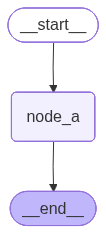

{'__interrupt__': [Interrupt(value='请输入您的姓名', id='c29ec6f0e190cdab6967cee8d4303250')]}


In [17]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


#1. 声明状态
class OverAllState(TypedDict):
    username:str

#2. 声明节点
def node_a(state:OverAllState)->OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username":username
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_edge(START,"node_a")
builder.add_edge("node_a",END)

#4. 想要使用中断 => 必须配置检查点
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable":{"thread_id":"123"}}
interrupt_res = graph.invoke({},config=config)
print(interrupt_res)


In [18]:
prompt = interrupt_res['__interrupt__'][0].value
print(prompt)
username = input(prompt)
# 5. 恢复图的中断执行
resume_res = graph.invoke(Command(resume=username),config=config)
print(resume_res)

请输入您的姓名
{'username': '小王'}
